# 01 — Forward library and Bayesian grid inversion

Version 0, stages 1–3 (+ the handover to prognosis):

$$\text{forward library } \{a_i, F(a_i)\} \;\rightarrow\; y = F(a_\text{true}) + e \;\rightarrow\; p(a\mid y) \;\rightarrow\; a^{(i)} \sim p(a\mid y) \;\rightarrow\; \mathrm{RUL}^{(i)}$$

Until the BristolFE export exists, the forward library comes from the **toy ray model** in
`rul_pipeline.synthetic` (linear array on 20 mm steel, backwall-breaking crack: tip diffraction + corner trap).
It has the right *structure* (tx × rx × time FMC, geometric arrival times), not the right physics.
32 elements are used here to keep the notebook light; `scripts/run_v0.py` uses 64. All lengths in metres internally.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rul_pipeline.synthetic import toy_fmc_library, toy_fmc_truth, add_measurement_noise
from rul_pipeline.inversion import invert_grid, sample_posterior
from rul_pipeline.crack_growth import ParisModel
from rul_pipeline.prognosis import propagate_rul

MM = 1e-3
rng = np.random.default_rng(0)

## 1. Forward library

Canonical representation: `crack_sizes` (N,) in m, `responses` (N, tx, rx, time), `dims` naming every axis.
For a real export: `lib = rul_pipeline.io.load_forward_library("data/bristolfe/lib.mat")` (see `src/rul_pipeline/io/README.md`).

In [2]:
grid = np.round(np.arange(0.5, 5.0001, 0.1), 9) * MM
lib = toy_fmc_library(grid, n_elements=32)
print("crack sizes:", lib.n_candidates, "from", lib.crack_sizes[0] / MM, "to", lib.crack_sizes[-1] / MM, "mm")
print("responses:", lib.responses.shape, lib.dims)
print("fs = %.0f MHz, time window %.2f-%.2f us" % (lib.fs / 1e6, lib.time[0] * 1e6, lib.time[-1] * 1e6))
print({k: v for k, v in lib.metadata.items()})

crack sizes: 46 from 0.5 to 5.0 mm
responses: (46, 32, 32, 110) ('crack', 'tx', 'rx', 'time')
fs = 25 MHz, time window 4.09-8.45 us
{'n_elements': 32, 'pitch_m': 0.0006, 'f_c_Hz': 5000000.0, 'n_cycles': 5.0, 'c_m_per_s': 5900.0, 'thickness_m': 0.02, 'crack_x_m': 0.0, 'include_backwall': False, 'tip_amplitude': 0.3, 'corner_amplitude': 1.0}


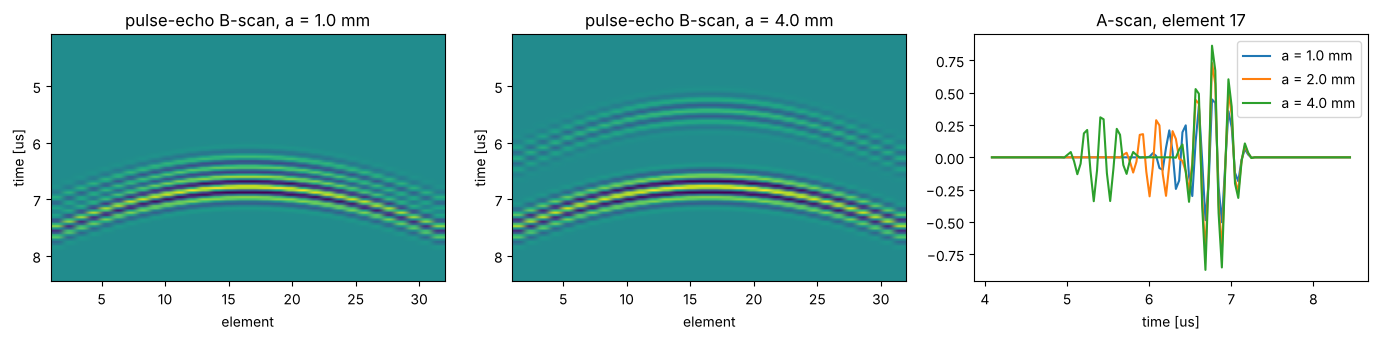

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
t_us = lib.time * 1e6
pe = lambda i: np.einsum("eet->et", lib.responses[i])          # pulse-echo (tx == rx) B-scan
for ax, i in zip(axs[:2], (5, 35)):
    ax.imshow(pe(i).T, aspect="auto", extent=[1, lib.measurement_shape[0], t_us[-1], t_us[0]])
    ax.set(xlabel="element", ylabel="time [us]", title=f"pulse-echo B-scan, a = {grid[i] / MM:.1f} mm")
e = lib.measurement_shape[0] // 2
for i in (5, 15, 35):
    axs[2].plot(t_us, lib.responses[i][e, e], label=f"a = {grid[i] / MM:.1f} mm")
axs[2].set(xlabel="time [us]", title=f"A-scan, element {e + 1}"); axs[2].legend()
fig.tight_layout()

The tip echo arrives *earlier* as the crack grows (tip moves toward the array); the corner-trap echo is fixed in time
and grows in amplitude. Both encode $a$.

## 2. Synthetic measurement and the posterior vs noise level

Truth $a_\text{true} = 2.03$ mm is **off-grid** and generated separately (`toy_fmc_truth`) to avoid the worst of the
"inverse crime". Noise is i.i.d. Gaussian with $\sigma$ set by a *peak* SNR, $\sigma = \max|F(a_\text{true})| / 10^{\text{SNR}/20}$.
The likelihood is

$$\log p(y\mid a_i) = -\frac{\lVert y - F(a_i)\rVert^2}{2\sigma^2} - \frac{M}{2}\log(2\pi\sigma^2).$$

SNR   10 dB: p(a | y): MAP = 2 mm, mean = 2 mm, std = 0 mm, 95% CI = [2, 2] mm
SNR  -10 dB: p(a | y): MAP = 2 mm, mean = 2 mm, std = 0.00205 mm, 95% CI = [2, 2] mm
SNR  -16 dB: p(a | y): MAP = 2.1 mm, mean = 2.173 mm, std = 0.248 mm, 95% CI = [2, 2.7] mm
SNR  -20 dB: p(a | y): MAP = 2.6 mm, mean = 2.86 mm, std = 0.328 mm, 95% CI = [2.6, 3.2] mm


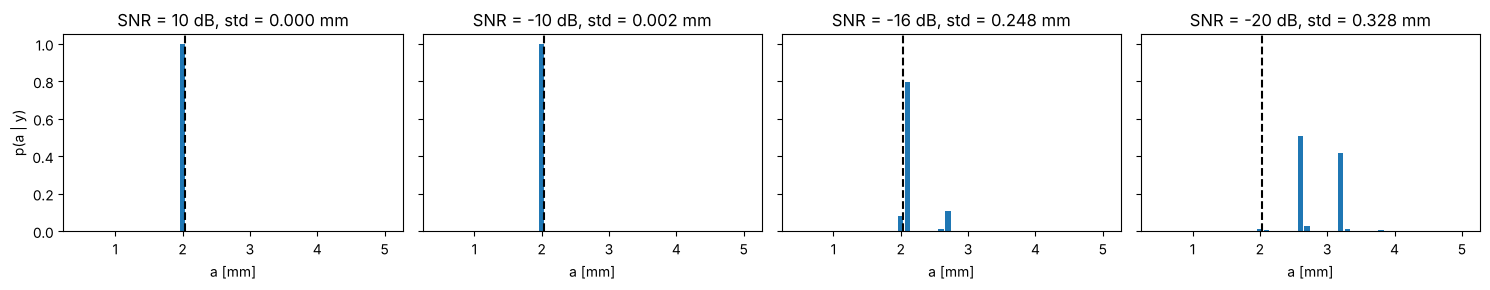

In [4]:
a_true = 2.03 * MM
y_clean = toy_fmc_truth(a_true, lib)
snrs = [10, -10, -16, -20]
fig, axs = plt.subplots(1, len(snrs), figsize=(15, 3), sharey=True)
posts = {}
for ax, snr in zip(axs, snrs):
    y, sigma = add_measurement_noise(y_clean, snr_db=snr, rng=rng)
    posts[snr] = post = invert_grid(y, lib, sigma)
    ax.bar(grid / MM, post.posterior, width=0.08)
    ax.axvline(a_true / MM, color="k", ls="--")
    ax.set(title=f"SNR = {snr} dB, std = {post.std / MM:.3f} mm", xlabel="a [mm]")
    print(f"SNR {snr:>4} dB: {post.summary()}")
axs[0].set_ylabel("p(a | y)"); fig.tight_layout()

**Observation.** With $M = 32 \times 32 \times n_t \approx 10^5$ samples treated as independent, the posterior collapses
onto a single grid point at any realistic SNR. Every sample is counted as independent information, so the i.i.d.
likelihood is over-confident whenever the real errors are correlated (band-limited noise, coherent grain noise,
model discrepancy). The demo script therefore uses a deliberately low *effective* SNR. Version 1 should replace
$\sigma^2 I$ with a covariance that includes a discrepancy term.

At the lowest SNR (−20 dB in this seeded realisation) the MAP sits at 2.6 mm, about one cycle-skip (≈ 0.59 mm,
see §3) above the truth, and the 95 % credible interval **excludes** $a_\text{true}$: the posterior is confidently
wrong. This is the multimodality that V0's 1-D grid can *represent* (it evaluates every candidate) but that
local optimisers or Gaussian approximations would miss.

## 3. Likelihood landscape and cycle skipping

Moving the tip by $\Delta a$ changes the pulse-echo path by $2\Delta a$, i.e. time by $2\Delta a / c$. One period at
$f_c$ = 5 MHz is matched when $\Delta a = c / (2 f_c) \approx 0.59$ mm, so the noise-free misfit
$\lVert F(a_\text{true}) - F(a_i)\rVert^2$ has secondary minima roughly one half-wavelength apart. Those minima
are the cause of the multimodal posteriors seen at low SNR.

c / (2 f_c) = 0.590 mm


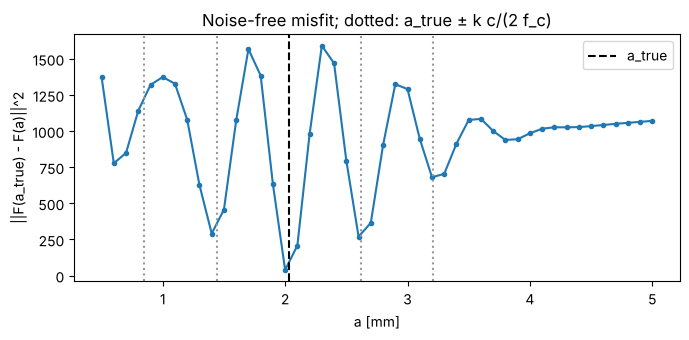

In [5]:
misfit = ((lib.flat_responses() - y_clean.reshape(-1)) ** 2).sum(axis=1)
lam_half = lib.metadata["c_m_per_s"] / (2 * lib.metadata["f_c_Hz"])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(grid / MM, misfit, marker=".")
for k in (-2, -1, 1, 2):
    ax.axvline((a_true + k * lam_half) / MM, color="0.6", ls=":")
ax.axvline(a_true / MM, color="k", ls="--", label="a_true")
ax.set(xlabel="a [mm]", ylabel="||F(a_true) - F(a)||^2", title="Noise-free misfit; dotted: a_true ± k c/(2 f_c)")
ax.legend(); fig.tight_layout()
print(f"c / (2 f_c) = {lam_half / MM:.3f} mm")

## 4. Probability handover: samples, not the MAP

$a^{(i)} \sim p(a\mid y)$ (jittered uniformly within each grid cell), then
$\Delta K^{(i)} = Y\Delta\sigma\sqrt{\pi a^{(i)}}$ and $\mathrm{RUL}^{(i)} = H(a^{(i)})$ with the BS 7910 steel-in-air
Paris law ($C = 1.65\times10^{-29}$ SI, $m = 3$), $\Delta\sigma = 100$ MPa, $a_c = 10$ mm.

p(a | y): MAP = 2.1 mm, mean = 2.173 mm, std = 0.248 mm, 95% CI = [2, 2.7] mm
p(RUL | y): median = 1.832e+05, mean = 1.788e+05, std = 1.52e+04 cycles, 90% CI = [1.429e+05, 1.908e+05] cycles, P(a >= a_c now) = 0
plug-in RUL(a_MAP) = 1.834e+05 cycles, RUL(E[a]) = 1.777e+05


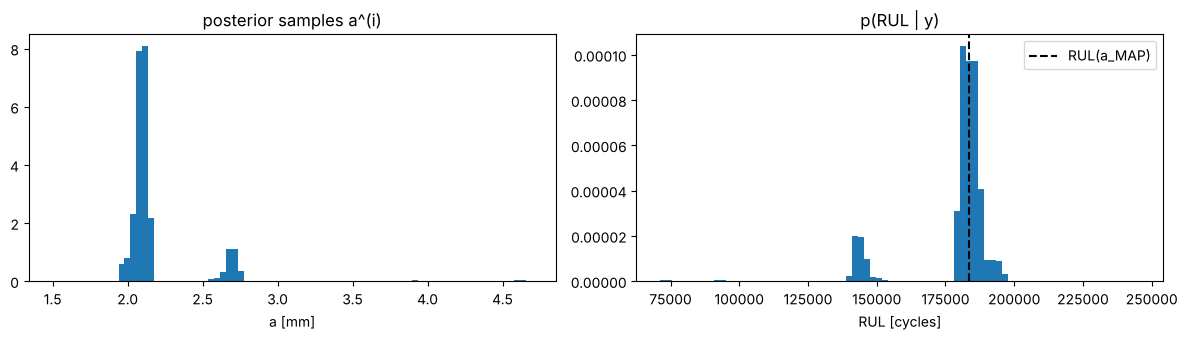

In [6]:
post = posts[-16]
a_s = sample_posterior(post, 20_000, rng=rng, jitter=True)
model = ParisModel(delta_sigma=100e6)
res = propagate_rul(a_s, model, a_c=10 * MM)
print(post.summary()); print(res.summary())
print(f"plug-in RUL(a_MAP) = {model.rul(post.map, 10 * MM):.4g} cycles, RUL(E[a]) = {model.rul(post.mean, 10 * MM):.4g}")
fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))
axs[0].hist(a_s / MM, bins=80, density=True); axs[0].set(xlabel="a [mm]", title="posterior samples a^(i)")
axs[1].hist(res.rul_samples, bins=80, density=True); axs[1].axvline(model.rul(post.map, 10 * MM), color="k", ls="--", label="RUL(a_MAP)")
axs[1].set(xlabel="RUL [cycles]", title="p(RUL | y)"); axs[1].legend(); fig.tight_layout()

Any secondary posterior mode in $a$ maps to a separate mode in RUL. A single plug-in value cannot represent
that, and because $\mathrm{RUL}(a)$ is convex, $\mathbb{E}[\mathrm{RUL}] \ge \mathrm{RUL}(\mathbb{E}[a])$ (Jensen).

**Next:** replace the toy library with the BristolFE export (schema in `matlab/export_forward_library.m`) and re-run this notebook unchanged.